# ADAM: Speeding Up Gradient Descent

 1) Learning rate decay     (by default, d = 0)
 
   learning rate $\alpha = \frac{\alpha_0}{1+d\cdot epoch}$ where $d$ is the decay parameter
   
 2) moving average
 
   time series: $x_1,x_2,\ldots,x_n$
   
   average $A_i = \frac{\sum x_j}{i}$
   
   --> can instead write as $A_i=x_n/n +(n-1)A_{n-1}/n$
   
 3) Exponential Moving Average
 
   $A_n = 1\;\; (n=1);\;\; A_n=\beta x_n+(1-\beta)A_{n-1}\;\; (n>1)$
   
 4) momentum
 
   (new) momentum = $\beta_1\cdot $momentum (previous) + $(1-\beta_1)\cdot $gradient
   
   momentum = average of the past gradients
   
   initial momentum = 0
   
   corrected momentum = momentum / $(1-\beta_1^{epoch+1})$
   
   By default, $\beta_1 = 0.9$
   
 5) adaptive learning rate
   
   idea: if past gradients are large, then decrease $\alpha$. if past gradients are small, then increase $\alpha$
   
   
 6) cache
 
 (new) cache = $\beta_2\cdot $cache (previous) + $(1-\beta_2)\cdot $gradient$^2$
 
 initial cache = 0
 
 corrected cache = $\frac{cache}{1+b_2^{epoch+1}}$
 
 7) alpha
 
 (new) $\alpha$ = $\frac{\alpha\;(prev)}{\sqrt{corrected cache}+\epsilon}
 
 $\epsilon = 1e-7$
 
 8) new weight / bias
 
 (new) weight = weight (prev) - $\alpha$ (new)$\cdot$ corrected momentum
 
 ****

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# neural network layer

class layer:
    # initialization
    def __init__(self, n_inputs,n_neurons): # self represents the instance of the class
        self.weights = 0.1*np.random.randn(n_inputs,n_neurons)# small random numbers
        self.biases = np.zeros((1,n_neurons)) #zeros
        
        #momentums and caches
        self.weight_momentums = np.zeros(self.weights.shape)
        self.bias_momentums = np.zeros(self.biases.shape)
        self.weight_cache = np.zeros(self.weights.shape)
        self.bias_cache = np.zeros(self.biases.shape)
        
    def forward(self, inputs):
        
        # we need to store the outputs
        self.output = inputs.dot(self.weights)+self.biases
        
        #as well as the inputs
        self.inputs = inputs
        
    def backward(self, dinputs):
        
        self.dinputs = dinputs.dot(self.weights.T)
        self.dweights = self.inputs.T.dot(dinputs)
        self.dbiases = np.sum(dinputs, axis=0,keepdims = True)
        
        
# ReLU activation function
class ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0,inputs)
        self.inputs = inputs
        
    def backward(self,dinputs): 
        self.dinputs = dinputs.copy()
        self.dinputs[self.inputs<0]=0
        

# linear activation function

class linear:
    # f(x) = x
    def forward(self,inputs):
        self.output = inputs.flatten()
        self.inputs = inputs
        
    def backward(self, dinputs):
        self.dinputs = dinputs.copy().reshape(-1,1)
        
# softmax activation function
class softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs)
        probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
        self.output = probabilities
        self.input = inputs
    
    def backward(self,dinputs):
        # initialize derivative matrix
        self.dinputs = np.zeros(dinputs.shape)
        for i in range(len(dinputs)):
            proba = self.output[i]
            dinputs_row = dinputs[i]
            derivative_matrix = np.diag(proba)-proba.reshape(-1,1).dot(proba.reshape(1,-1))
            self.dinputs[i] = dinputs_row.dot(derivative_matrix)
        
        
# categorical cross entropy

class loss_cross_entropy:
    def forward(self,P,y):
        # number of data points
        n_samples = len(y)
        
        # clip P to prevent division by zero
        P_clipped = np.clip(P,1e-7,1-1e-7)
        
        # 
        pred_probabilities = P_clipped[np.arange(n_samples),y]
        
        losses = -np.log(pred_probabilities)
        return losses 
    
    def backward(self,P,y):
        # number of data points
        n_samples = len(y)
        
        # one-hot encoding matrix
        Y = np.zeros(P.shape)
        Y[np.arange(n_samples),y]=1
        
        # derivatives
        self.dinputs = -Y/P/n_samples



# loss function
class loss_mse:
    def forward(self,yhat,y):
        losses = (y-yhat)**2 # this is a vector but we need to compute the mean of its entries
        return losses
    
    def backward(self,yhat, y):
        self.dinputs = (-2/len(y))*(y-yhat)
        
#optimizer

class optimizer_GD:
    def __init__(self, learning_rate):
        self.learning_rate=learning_rate
        
    def update_parameters(self,layer):
        layer.weights = layer.weights - self.learning_rate*layer.dweights
        layer.biases = layer.biases - self.learning_rate*layer.dbiases
        
        
        
# ADAM optimizer

class optimizer_ADAM:
    
    def __init__(self,learning_rate,decay=0,epsilon=1e-7,beta1=0.9,beta2=0.999):
        self.learning_rate = learning_rate
        self.decay = decay
        self.epsilon = epsilon
        self.beta1 = beta1
        self.beta2 = beta2
        self.epoch=0
        
    #update learning rate
    def pre_update_parameters(self):
        self.current_learning_rate = self.learning_rate/(1+self.decay*self.epoch)
        
    #update parameters
    def update_parameters(self,layer):
        # momentum
        layer.weight_momentums = self.beta1*layer.weight_momentums+(1-self.beta1)*layer.dweights
        layer.bias_momentums = self.beta1*layer.bias_momentums+(1-self.beta1)*layer.dbiases
        
        
        # corrected momentum
        weight_momentums_corrected = layer.weight_momentums/(1-self.beta1**(self.epoch+1))
        bias_weights_corrected = layer.bias_momentums/(1-self.beta1**(self.epoch+1))
        
        # cache
        layer.weight_caches = self.beta2*layer.weight_caches+(1-self.beta2)*layer.dweights**2
        layer.bias_caches = self.beta2*layer.bias_caches+(1-self.beta2)*layer.dbiases**2
        
        
        # corrected cache
        weight_caches_corrected = layer.weight_caches/(1-self.beta2**(self.epoch+1))
        bias_caches_corrected = layer.bias_caches/(1-self.beta2**(self.epoch+1))
        
        # update weights and biases
        layer.weights += -self.current_learning_rate*weight_momentums.corrected / (self.epsilon+np.sqrt(weight_caches_corrected))
        layer.biases += -self.current_learning_rate*bias_momentums.corrected / (self.epsilon+np.sqrt(bias_caches_corrected))
        
        #update epoch
        
    def post_update_parameters(self):
        self.epoch+=1

        
# dropout layer
class dropout:
    def __init__(self,rate):
        self.rate =rate
    def forward(self,inputs):
        self.inputs = inputs
        self.mask = np.random.binomial(1,1-rate,size=inputs.shape)
        self.output = inputs*self.mask/(1-rate)
    def backward(self,dinputs):
        self.dinputs = self.mask*dinputs

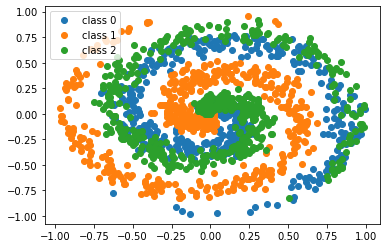

In [6]:
# generate toy dataset
classes = 3
n_points = 500
noise = 0.55
radius = 9

X = np.zeros((n_points*classes, 2))
y = np.zeros(n_points*classes).astype('int')

for class_number in range(classes):
    ix = range(n_points*class_number, n_points*(class_number+1))
    r = np.linspace(0,1, n_points)
    t = np.linspace(class_number*radius, (class_number+1)*radius, n_points) + np.random.randn(n_points)*noise
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = class_number
    
for i in range(classes):
    plt.plot(X[y==i,0],X[y==i,1],'o',label = 'class '+str(i))
plt.legend()